## 1. Import Libraries

In [1]:
import matplotlib.pyplot as plt
from qiskit_ibm_runtime.fake_provider import FakeBrisbane, FakeSherbrooke
import rustworkx as rx
from qiskit.visualization import plot_gate_map

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Backend

FakeBrisbane is a 127-qubit Eagle processor with the **Heavy Hex** topology - IBM's signature layout optimized for error correction.

In [2]:
# Load the backend
try:
    backend = FakeBrisbane()
    name = "FakeBrisbane"
except ImportError:
    # Fallback for older qiskit versions
    from qiskit.providers.fake_provider import FakeBrisbane
    backend = FakeBrisbane()
    name = "FakeBrisbane (Legacy)"

print(f"Backend Loaded: {name}")
print(f"Qubit Count: {backend.num_qubits}")
print(f"Basis Gates: {backend.operation_names}")

Backend Loaded: FakeBrisbane
Qubit Count: 127
Basis Gates: ['measure', 'x', 'switch_case', 'if_else', 'ecr', 'rz', 'sx', 'reset', 'for_loop', 'id', 'delay']


## 3. Visualize the Chip Topology

The coupling map shows which qubits can directly interact via 2-qubit gates. This **is** the graph your routing algorithms must solve - you can only do CX/CZ gates between connected qubits.

Generating Chip Layout (may take a moment for 127 qubits)...


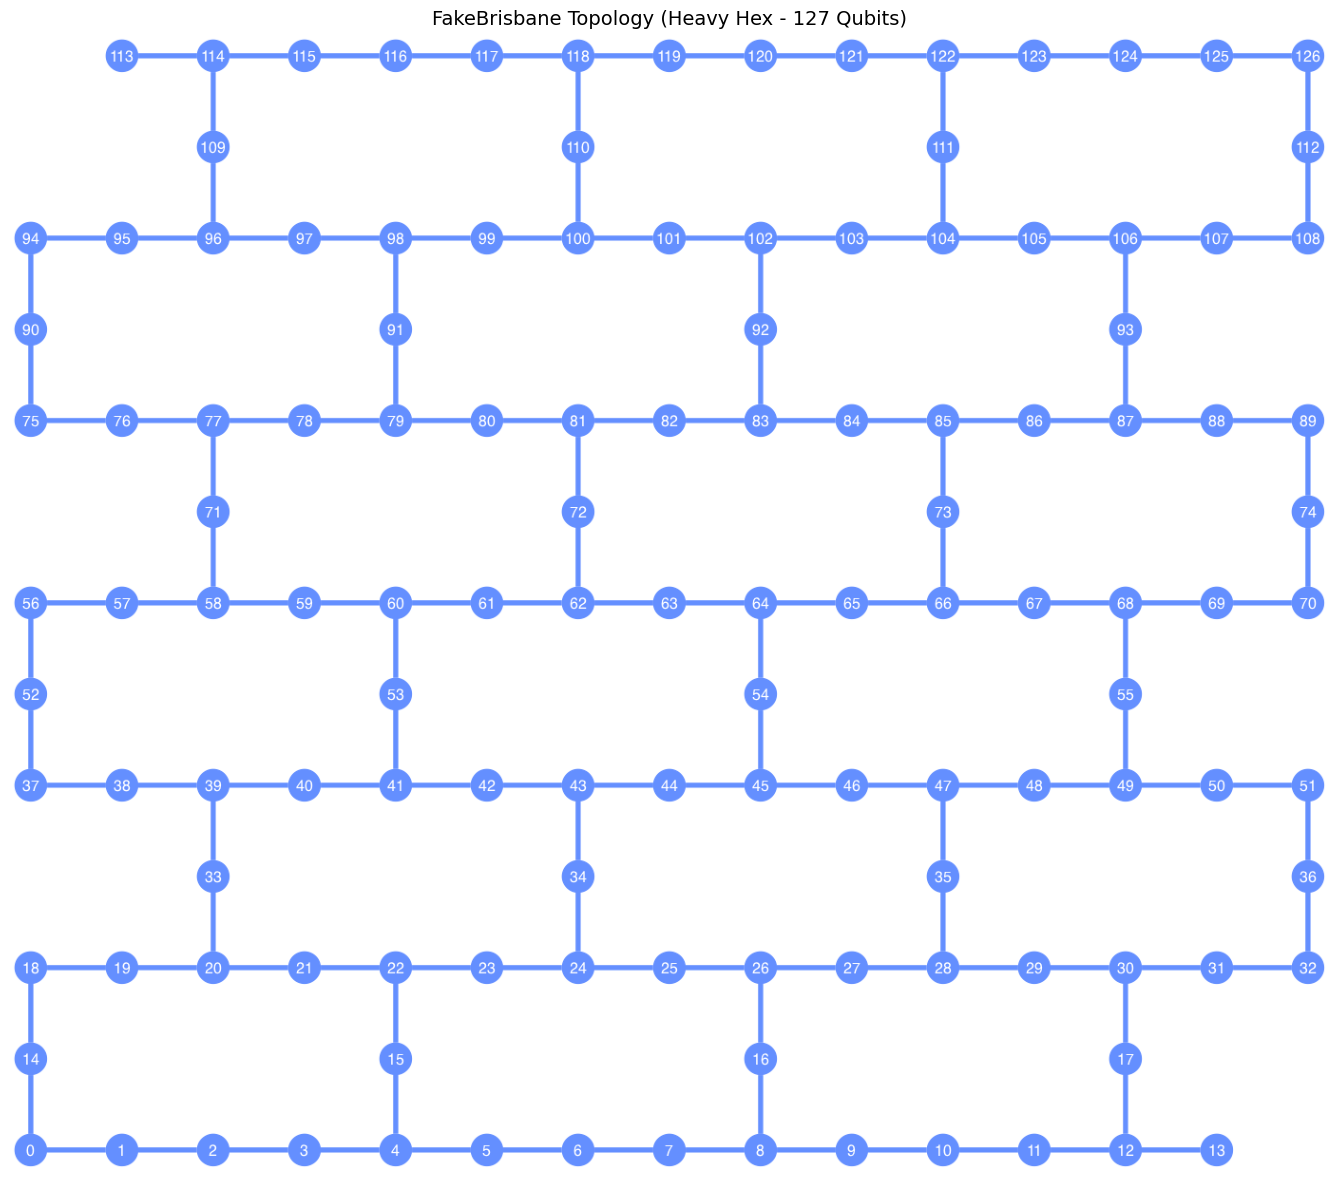

In [3]:
# Visualize the chip layout
# Note: This plot might be slow for 127 qubits
print("Generating Chip Layout (may take a moment for 127 qubits)...")

# Method 1: Try plot_gate_map (returns a matplotlib figure)
try:
    fig = plot_gate_map(backend, plot_directed=False, figsize=(14, 12))
    fig.suptitle(f"{name} Topology (Heavy Hex - 127 Qubits)", fontsize=14)
    fig.tight_layout()
    display(fig)
except Exception as e:
    print(f"plot_gate_map failed: {e}")
    
    # Method 2: Fallback - build graph manually with rustworkx
    print("\nUsing rustworkx visualization instead...")
    from rustworkx.visualization import mpl_draw
    
    coupling_edges = backend.coupling_map.get_edges()
    hw_graph = rx.PyGraph()
    hw_graph.add_nodes_from(range(backend.num_qubits))
    hw_graph.add_edges_from_no_data(coupling_edges)
    
    fig, ax = plt.subplots(figsize=(16, 12))
    mpl_draw(hw_graph,
             ax=ax,
             with_labels=True,
             labels=lambda x: str(x),
             node_size=200,
             font_size=6,
             node_color='#3498db',
             edge_color='#95a5a6')
    ax.set_title(f"{name} Topology (Heavy Hex - 127 Qubits)", fontsize=14)
    plt.tight_layout()
    plt.show()

## 4. Inspect the Noise Properties

This proves FakeBrisbane isn't just a perfect simulator - it has real, calibrated noise data from a specific date.

### Key Metrics:
- **T1 (Energy Relaxation)**: How long until a |1⟩ state decays to |0⟩
- **T2 (Dephasing)**: How long until a superposition loses its phase coherence
- **Gate Error**: Probability of an incorrect result from a gate operation

In [4]:
# Get backend properties
props = backend.properties()

# Calculate average T1 across all qubits
t1_times = [props.t1(i) for i in range(backend.num_qubits)]
t2_times = [props.t2(i) for i in range(backend.num_qubits)]

avg_t1 = sum(t1_times) / len(t1_times)
avg_t2 = sum(t2_times) / len(t2_times)

print(f"=== {name} VITALS ===")
print(f"Snapshot Date: {props.last_update_date}")
print(f"\nCoherence Times:")
print(f"  Average T1: {avg_t1*1e6:.2f} μs")
print(f"  Average T2: {avg_t2*1e6:.2f} μs")
print(f"  T1 Range: [{min(t1_times)*1e6:.1f}, {max(t1_times)*1e6:.1f}] μs")
print(f"  T2 Range: [{min(t2_times)*1e6:.1f}, {max(t2_times)*1e6:.1f}] μs")

=== FakeBrisbane VITALS ===
Snapshot Date: 2025-02-26 14:33:06-05:00

Coherence Times:
  Average T1: 233.71 μs
  Average T2: 160.58 μs
  T1 Range: [9.9, 425.2] μs
  T2 Range: [17.1, 411.5] μs


In [5]:
# Check gate errors on specific connections
print("=== Sample Link Errors ===")

# Get a few sample connections
coupling_map = backend.coupling_map
sample_edges = list(coupling_map.get_edges())[:5]

for q1, q2 in sample_edges:
    try:
        cx_err = props.gate_error('cx', [q1, q2])
        print(f"  Link {q1:3d} <-> {q2:3d} CNOT Error: {cx_err:.4%}")
    except:
        print(f"  Link {q1:3d} <-> {q2:3d} CNOT Error: Not reported")

=== Sample Link Errors ===
  Link   1 <->   0 CNOT Error: Not reported
  Link   2 <->   1 CNOT Error: Not reported
  Link   3 <->   2 CNOT Error: Not reported
  Link   4 <->   3 CNOT Error: Not reported
  Link   4 <->   5 CNOT Error: Not reported


## 5. Visualize Coherence Distribution

Let's see how T1/T2 times vary across the chip - some qubits are better than others!

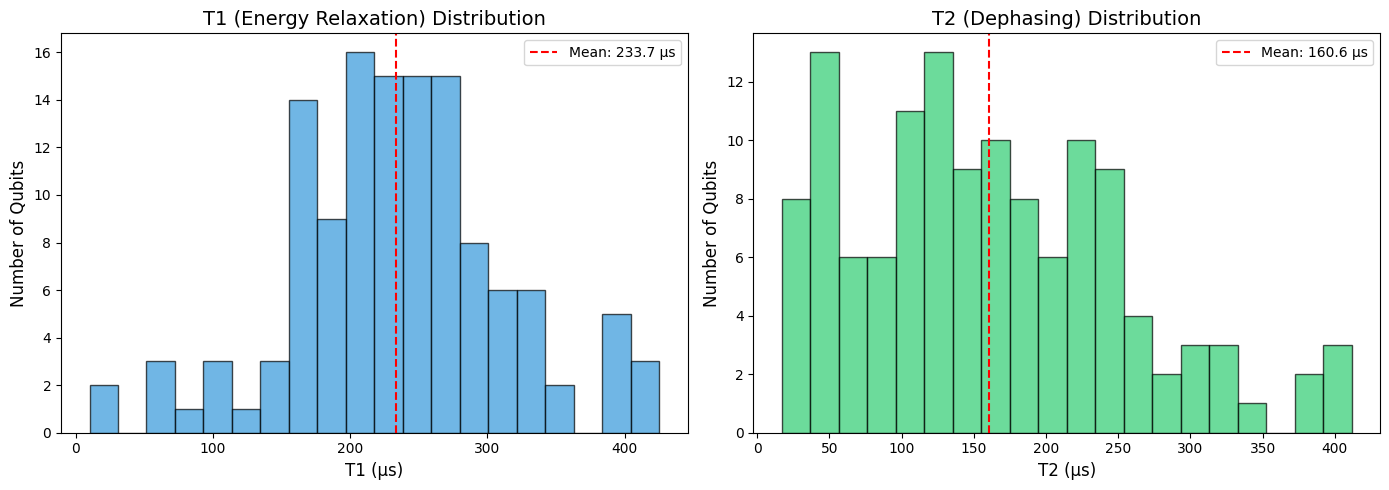


Best T1 qubit: 23 (425.2 μs)
Worst T1 qubit: 119 (9.9 μs)


In [6]:
# Plot T1/T2 distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# T1 histogram
axes[0].hist([t*1e6 for t in t1_times], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(avg_t1*1e6, color='red', linestyle='--', label=f'Mean: {avg_t1*1e6:.1f} μs')
axes[0].set_xlabel('T1 (μs)', fontsize=12)
axes[0].set_ylabel('Number of Qubits', fontsize=12)
axes[0].set_title('T1 (Energy Relaxation) Distribution', fontsize=14)
axes[0].legend()

# T2 histogram
axes[1].hist([t*1e6 for t in t2_times], bins=20, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1].axvline(avg_t2*1e6, color='red', linestyle='--', label=f'Mean: {avg_t2*1e6:.1f} μs')
axes[1].set_xlabel('T2 (μs)', fontsize=12)
axes[1].set_ylabel('Number of Qubits', fontsize=12)
axes[1].set_title('T2 (Dephasing) Distribution', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

# Identify best and worst qubits
best_t1_qubit = t1_times.index(max(t1_times))
worst_t1_qubit = t1_times.index(min(t1_times))

print(f"\nBest T1 qubit: {best_t1_qubit} ({max(t1_times)*1e6:.1f} μs)")
print(f"Worst T1 qubit: {worst_t1_qubit} ({min(t1_times)*1e6:.1f} μs)")

## Summary

FakeBrisbane provides a realistic simulation environment with:
- **127 qubits** in a Heavy Hex topology
- **Real calibration data** from IBM hardware
- **Varying qubit quality** - some qubits are better than others

This makes it ideal for testing quantum algorithms under realistic noise conditions before deploying to actual hardware.

## 6. Verify Topology for ⟨3,1,1⟩ Code Transport

Let's verify if our proposed qubit layout is valid:
- **Source**: 58-71-77 (encoding cluster)
- **Destination**: 41-53-60 (after transport)
- **Ancillas**: 42 (for Z₁Z₂), 61 (for Z₂Z₃)

In [7]:
# ==========================================
# VERIFY TOPOLOGY FOR THE PROPOSED EXPERIMENT
# ==========================================

# Build undirected graph for analysis
coupling_edges = backend.coupling_map.get_edges()
hw_graph = rx.PyGraph()
hw_graph.add_nodes_from(range(backend.num_qubits))
hw_graph.add_edges_from_no_data(coupling_edges)

def get_neighbors(graph, qubit):
    """Get all neighbors of a qubit."""
    neighbors = set()
    for edge in graph.edge_list():
        if edge[0] == qubit:
            neighbors.add(edge[1])
        elif edge[1] == qubit:
            neighbors.add(edge[0])
    return sorted(neighbors)

def check_connection(graph, q1, q2):
    """Check if two qubits are directly connected."""
    return q2 in get_neighbors(graph, q1)

print("=" * 60)
print("TOPOLOGY VERIFICATION FOR ⟨3,1,1⟩ CODE TRANSPORT")
print("=" * 60)

# Source cluster
print("\n📍 SOURCE CLUSTER (58-71-77):")
print(f"   Qubit 58 neighbors: {get_neighbors(hw_graph, 58)}")
print(f"   Qubit 71 neighbors: {get_neighbors(hw_graph, 71)}")
print(f"   Qubit 77 neighbors: {get_neighbors(hw_graph, 77)}")
print(f"   ✓ 58-71 connected: {check_connection(hw_graph, 58, 71)}")
print(f"   ✓ 71-77 connected: {check_connection(hw_graph, 71, 77)}")

# Destination cluster  
print("\n📍 DESTINATION CLUSTER (41-53-60):")
print(f"   Qubit 41 neighbors: {get_neighbors(hw_graph, 41)}")
print(f"   Qubit 53 neighbors: {get_neighbors(hw_graph, 53)}")
print(f"   Qubit 60 neighbors: {get_neighbors(hw_graph, 60)}")
print(f"   ✓ 41-53 connected: {check_connection(hw_graph, 41, 53)}")
print(f"   ✓ 53-60 connected: {check_connection(hw_graph, 53, 60)}")

# Ancilla connectivity (CRITICAL for syndrome measurement)
print("\n📍 ANCILLA CONNECTIVITY:")
print(f"   Qubit 42 neighbors: {get_neighbors(hw_graph, 42)}")
print(f"   Qubit 61 neighbors: {get_neighbors(hw_graph, 61)}")
print(f"   ✓ 42-41 connected: {check_connection(hw_graph, 42, 41)}")
print(f"   ✓ 42-53 connected: {check_connection(hw_graph, 42, 53)}")
print(f"   ✓ 61-53 connected: {check_connection(hw_graph, 61, 53)}")
print(f"   ✓ 61-60 connected: {check_connection(hw_graph, 61, 60)}")

TOPOLOGY VERIFICATION FOR ⟨3,1,1⟩ CODE TRANSPORT

📍 SOURCE CLUSTER (58-71-77):
   Qubit 58 neighbors: [57, 59, 71]
   Qubit 71 neighbors: [58, 77]
   Qubit 77 neighbors: [71, 76, 78]
   ✓ 58-71 connected: True
   ✓ 71-77 connected: True

📍 DESTINATION CLUSTER (41-53-60):
   Qubit 41 neighbors: [40, 42, 53]
   Qubit 53 neighbors: [41, 60]
   Qubit 60 neighbors: [53, 59, 61]
   ✓ 41-53 connected: True
   ✓ 53-60 connected: True

📍 ANCILLA CONNECTIVITY:
   Qubit 42 neighbors: [41, 43]
   Qubit 61 neighbors: [60, 62]
   ✓ 42-41 connected: True
   ✓ 42-53 connected: False
   ✓ 61-53 connected: False
   ✓ 61-60 connected: True


In [8]:
# ==========================================
# FIND BETTER ANCILLA OPTIONS
# ==========================================

print("=" * 60)
print("SEARCHING FOR VALID SYNDROME MEASUREMENT OPTIONS")
print("=" * 60)

# For Z₁Z₂ syndrome (qubits 41, 53), we need an ancilla connected to BOTH
print("\n🔍 Looking for ancilla connected to BOTH 41 AND 53:")
neighbors_41 = set(get_neighbors(hw_graph, 41))
neighbors_53 = set(get_neighbors(hw_graph, 53))
common_41_53 = neighbors_41 & neighbors_53
print(f"   Common neighbors of 41 and 53: {common_41_53 if common_41_53 else 'NONE'}")

# For Z₂Z₃ syndrome (qubits 53, 60), we need an ancilla connected to BOTH
print("\n🔍 Looking for ancilla connected to BOTH 53 AND 60:")
neighbors_60 = set(get_neighbors(hw_graph, 60))
common_53_60 = neighbors_53 & neighbors_60
print(f"   Common neighbors of 53 and 60: {common_53_60 if common_53_60 else 'NONE'}")

print("\n" + "=" * 60)
print("ALTERNATIVE: Use qubit 53 itself for syndrome extraction")
print("=" * 60)
print("""
Since 53 is the middle qubit, we can measure syndromes differently:

Option A: Sequential parity checks with SWAPs
  - Use 41's neighbor (42) for Z₁Z₂ after swapping 53↔41
  - Use 60's neighbor (61) for Z₂Z₃ after swapping 53↔60

Option B: Direct measurement approach  
  - Measure Z₁Z₂: CNOT(41→ancilla), CNOT(53→ancilla), measure ancilla
  - But this requires ancilla connected to both...

Option C: Reconsider the destination cluster layout
""")

# Let's find a better destination cluster where syndrome is easier
print("\n🔍 SEARCHING FOR BETTER DESTINATION CLUSTERS...")
print("   Looking for 3-qubit chains where middle qubit has 3+ neighbors...\n")

good_clusters = []
for q in range(backend.num_qubits):
    neighbors = get_neighbors(hw_graph, q)
    if len(neighbors) >= 2:
        # Check if any pair of neighbors forms a chain through q
        for i, n1 in enumerate(neighbors):
            for n2 in neighbors[i+1:]:
                # n1-q-n2 forms a chain
                # Check if there's a common neighbor to n1 and q (for Z₁Z₂)
                common_n1_q = set(get_neighbors(hw_graph, n1)) & set(get_neighbors(hw_graph, q))
                common_n1_q.discard(n1)  # Remove self
                common_n1_q.discard(n2)  # Remove the other chain qubit
                
                common_q_n2 = set(get_neighbors(hw_graph, q)) & set(get_neighbors(hw_graph, n2))
                common_q_n2.discard(n1)
                common_q_n2.discard(q)
                
                if common_n1_q and common_q_n2:
                    good_clusters.append({
                        'chain': (n1, q, n2),
                        'ancilla_12': list(common_n1_q)[0],
                        'ancilla_23': list(common_q_n2)[0]
                    })

print(f"Found {len(good_clusters)} clusters with ideal syndrome connectivity!")
if good_clusters[:5]:
    print("\nTop 5 options:")
    for i, c in enumerate(good_clusters[:5]):
        print(f"   {i+1}. Chain {c['chain']}, ancillas: {c['ancilla_12']} (Z₁Z₂), {c['ancilla_23']} (Z₂Z₃)")

SEARCHING FOR VALID SYNDROME MEASUREMENT OPTIONS

🔍 Looking for ancilla connected to BOTH 41 AND 53:
   Common neighbors of 41 and 53: NONE

🔍 Looking for ancilla connected to BOTH 53 AND 60:
   Common neighbors of 53 and 60: NONE

ALTERNATIVE: Use qubit 53 itself for syndrome extraction

Since 53 is the middle qubit, we can measure syndromes differently:

Option A: Sequential parity checks with SWAPs
  - Use 41's neighbor (42) for Z₁Z₂ after swapping 53↔41
  - Use 60's neighbor (61) for Z₂Z₃ after swapping 53↔60

Option B: Direct measurement approach  
  - Measure Z₁Z₂: CNOT(41→ancilla), CNOT(53→ancilla), measure ancilla
  - But this requires ancilla connected to both...

Option C: Reconsider the destination cluster layout


🔍 SEARCHING FOR BETTER DESTINATION CLUSTERS...
   Looking for 3-qubit chains where middle qubit has 3+ neighbors...

Found 0 clusters with ideal syndrome connectivity!


### Syndrome Measurement Options

The Heavy Hex topology doesn't have clusters where a single ancilla connects to two adjacent data qubits. Here are two practical approaches:

**Option A: Sequential CNOTs through the chain**
```
For Z₁Z₂ (parity of 41, 53):
  ancilla=42 ── CNOT ← 41 ── CNOT ← 53 (via SWAP to bring 53 closer)
  
For Z₂Z₃ (parity of 53, 60):
  ancilla=61 ── CNOT ← 60 ── CNOT ← 53 (via SWAP)
```

**Option B: Use the middle qubit (53) as syndrome carrier**
```
Z₁Z₂: CNOT(41, 53), then CNOT(53, ancilla_near_53)
Z₂Z₃: CNOT(60, 53), then measure 53 directly
```

Let's verify Option A is feasible with your layout:

In [9]:
# ==========================================
# PRACTICAL SYNDROME MEASUREMENT CIRCUIT
# ==========================================

print("=" * 60)
print("PRACTICAL APPROACH: Syndrome via CNOT chains")
print("=" * 60)

# Your layout:
# Destination: 41 - 53 - 60  (the encoded qubits after transport)
# Ancillas:    42       61

print("""
SYNDROME CIRCUIT DESIGN:

For Z₁Z₂ (parity of qubits 41 and 53):
  Since 42 connects to 41 but not 53, we can:
  1. CNOT(41 → 42)  [42 now has bit value of 41]
  2. SWAP(41 ↔ 53)  [bring 53 to position 41]  
  3. CNOT(41 → 42)  [42 now has XOR of original 41,53]
  4. SWAP(41 ↔ 53)  [restore positions]
  5. Measure 42 → gives Z₁Z₂ syndrome

For Z₂Z₃ (parity of qubits 53 and 60):
  Since 61 connects to 60 but not 53, we can:
  1. CNOT(60 → 61)  [61 now has bit value of 60]
  2. SWAP(60 ↔ 53)  [bring 53 to position 60]
  3. CNOT(60 → 61)  [61 now has XOR of original 53,60]
  4. SWAP(60 ↔ 53)  [restore positions]
  5. Measure 61 → gives Z₂Z₃ syndrome
""")

print("✅ This approach works with your chosen qubits!")
print("\n" + "=" * 60)
print("SIMPLER ALTERNATIVE: Direct stabilizer measurement")
print("=" * 60)
print("""
Actually, since 41-53 and 53-60 are connected, we can use 
a simpler approach that measures stabilizers directly:

For Z₁Z₂:
  1. CNOT(41 → 53)  [53 now has XOR(41,53)]
  2. Measure 53 in Z basis → gives Z₁Z₂
  3. CNOT(41 → 53)  [undo to restore state]

For Z₂Z₃: 
  1. CNOT(60 → 53)  [53 now has XOR(53,60)]
  2. Measure 53 → gives Z₂Z₃
  
But this is destructive... Let me think about non-destructive option.
""")

# Actually, let's check what qubits 53 can reach
print("\n🔍 Qubits reachable from 53 (for ancilla placement):")
print(f"   Direct neighbors of 53: {get_neighbors(hw_graph, 53)}")
print(f"   → 41 and 60 are the data qubits")
print(f"   → No spare ancilla directly on 53")

print("\n💡 RECOMMENDED APPROACH:")
print("""
Use 42 and 61 as ancillas with SWAP-based syndrome extraction.
This is actually realistic for near-term quantum error correction!

Full circuit:
1. Encode at 58-71-77
2. SWAP transport to 41-53-60  
3. Syndrome extraction (with SWAPs as described)
4. Decode based on syndrome
5. Measure logical qubit
""")

PRACTICAL APPROACH: Syndrome via CNOT chains

SYNDROME CIRCUIT DESIGN:

For Z₁Z₂ (parity of qubits 41 and 53):
  Since 42 connects to 41 but not 53, we can:
  1. CNOT(41 → 42)  [42 now has bit value of 41]
  2. SWAP(41 ↔ 53)  [bring 53 to position 41]  
  3. CNOT(41 → 42)  [42 now has XOR of original 41,53]
  4. SWAP(41 ↔ 53)  [restore positions]
  5. Measure 42 → gives Z₁Z₂ syndrome

For Z₂Z₃ (parity of qubits 53 and 60):
  Since 61 connects to 60 but not 53, we can:
  1. CNOT(60 → 61)  [61 now has bit value of 60]
  2. SWAP(60 ↔ 53)  [bring 53 to position 60]
  3. CNOT(60 → 61)  [61 now has XOR of original 53,60]
  4. SWAP(60 ↔ 53)  [restore positions]
  5. Measure 61 → gives Z₂Z₃ syndrome

✅ This approach works with your chosen qubits!

SIMPLER ALTERNATIVE: Direct stabilizer measurement

Actually, since 41-53 and 53-60 are connected, we can use 
a simpler approach that measures stabilizers directly:

For Z₁Z₂:
  1. CNOT(41 → 53)  [53 now has XOR(41,53)]
  2. Measure 53 in Z basis → 

SWAP TRANSPORT PATHS
Path 58 → 41: [58, 59, 60, 53, 41] (4 SWAPs)
Path 71 → 53: [71, 58, 59, 60, 53] (4 SWAPs)
Path 77 → 60: [77, 71, 58, 59, 60] (4 SWAPs)

Total SWAP operations: 12

All qubits involved: [41, 42, 53, 58, 59, 60, 61, 71, 77]


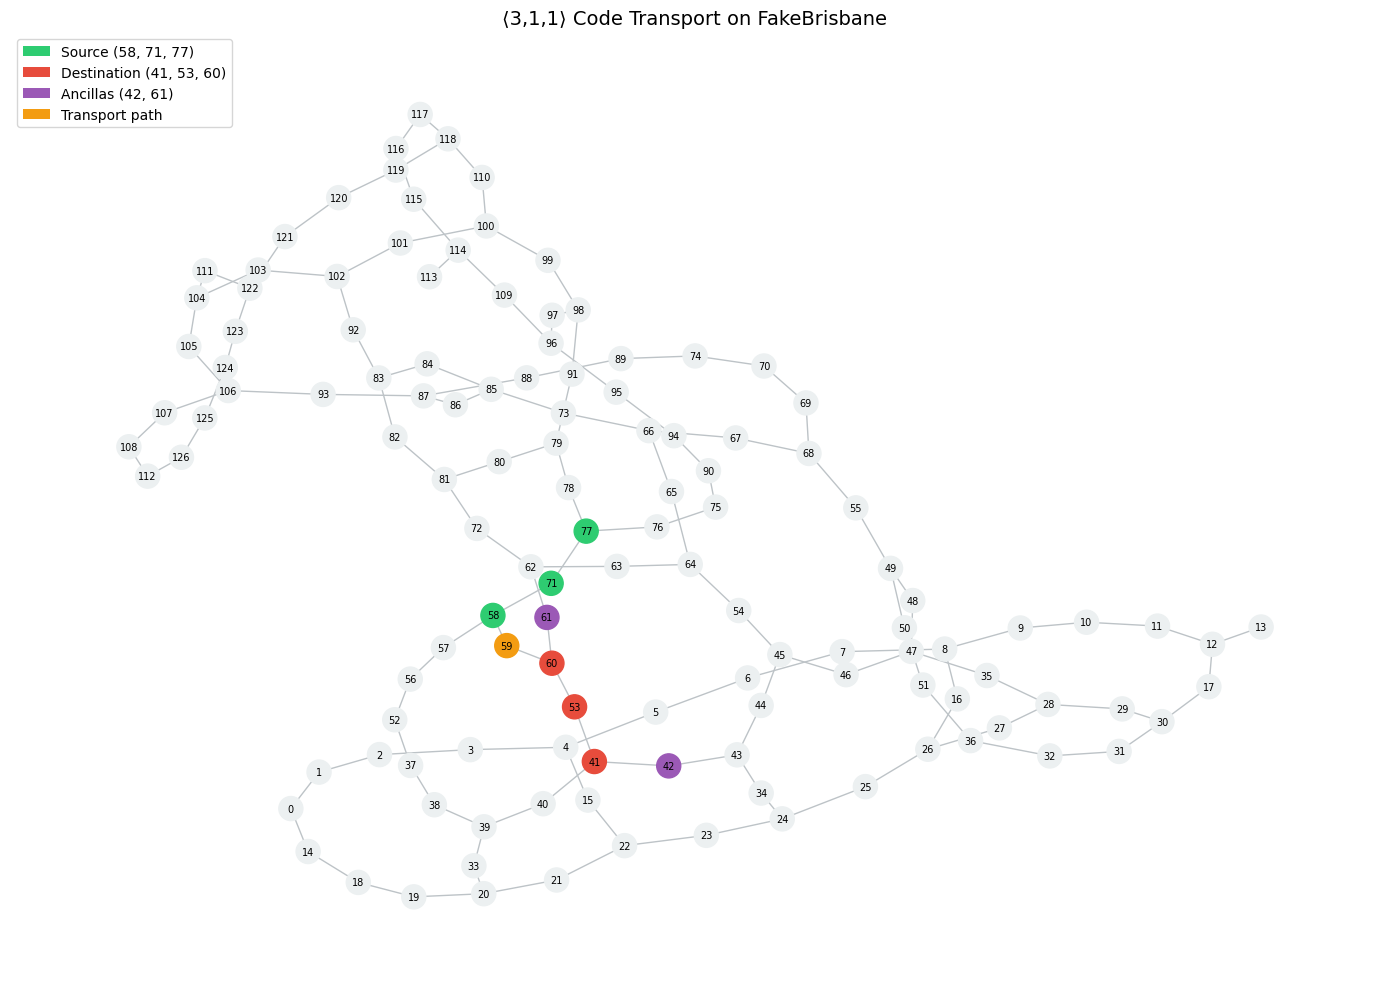

In [10]:
# ==========================================
# VISUALIZE THE TRANSPORT PATHS
# ==========================================
from rustworkx.visualization import mpl_draw
import rustworkx as rx

# Find SWAP paths from source to destination
path_58_to_41 = rx.dijkstra_shortest_paths(hw_graph, 58, 41)[41]
path_71_to_53 = rx.dijkstra_shortest_paths(hw_graph, 71, 53)[53]
path_77_to_60 = rx.dijkstra_shortest_paths(hw_graph, 77, 60)[60]

print("=" * 60)
print("SWAP TRANSPORT PATHS")
print("=" * 60)
print(f"Path 58 → 41: {list(path_58_to_41)} ({len(path_58_to_41)-1} SWAPs)")
print(f"Path 71 → 53: {list(path_71_to_53)} ({len(path_71_to_53)-1} SWAPs)")
print(f"Path 77 → 60: {list(path_77_to_60)} ({len(path_77_to_60)-1} SWAPs)")

total_swaps = (len(path_58_to_41)-1) + (len(path_71_to_53)-1) + (len(path_77_to_60)-1)
print(f"\nTotal SWAP operations: {total_swaps}")

# Collect all qubits involved
all_path_qubits = set(path_58_to_41) | set(path_71_to_53) | set(path_77_to_60)
source_qubits = {58, 71, 77}
dest_qubits = {41, 53, 60}
ancilla_qubits = {42, 61}

print(f"\nAll qubits involved: {sorted(all_path_qubits | ancilla_qubits)}")

# Visualize
fig, ax = plt.subplots(figsize=(14, 10))

# Color nodes by role
node_colors = []
for i in range(hw_graph.num_nodes()):
    if i in source_qubits:
        node_colors.append('#2ecc71')  # Green - source
    elif i in dest_qubits:
        node_colors.append('#e74c3c')  # Red - destination
    elif i in ancilla_qubits:
        node_colors.append('#9b59b6')  # Purple - ancilla
    elif i in all_path_qubits:
        node_colors.append('#f39c12')  # Orange - path
    else:
        node_colors.append('#ecf0f1')  # Light gray - unused

mpl_draw(hw_graph,
         ax=ax,
         with_labels=True,
         labels=lambda x: str(x),
         node_size=300,
         font_size=7,
         node_color=node_colors,
         edge_color='#bdc3c7')

ax.set_title("⟨3,1,1⟩ Code Transport on FakeBrisbane", fontsize=14)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Source (58, 71, 77)'),
    Patch(facecolor='#e74c3c', label='Destination (41, 53, 60)'),
    Patch(facecolor='#9b59b6', label='Ancillas (42, 61)'),
    Patch(facecolor='#f39c12', label='Transport path'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()